In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

daily = pd.read_csv("../data/processed/eurusd_con_sentimiento.csv",
                    index_col=0, parse_dates=True)

returns = daily['returns'].dropna()
print(f"Serie de retornos: {len(returns)} observaciones")
print(f"Período: {returns.index[0].date()} → {returns.index[-1].date()}")

Serie de retornos: 4031 observaciones
Período: 2010-10-08 → 2026-04-03


In [3]:
def hurst_exponent(series, max_lag=100):
    lags = range(2, max_lag)
    tau = []
    
    for lag in lags:
        subseries = [series[i:i+lag] for i in range(0, len(series)-lag, lag)]
        rs_values = []
        for sub in subseries:
            if len(sub) < 2:
                continue
            mean = np.mean(sub)
            deviation = np.cumsum(sub - mean)
            R = np.max(deviation) - np.min(deviation)
            S = np.std(sub, ddof=1)
            if S > 0:
                rs_values.append(R/S)
        if rs_values:
            tau.append(np.mean(rs_values))
    
    if len(tau) < 2:
        return 0.5
    
    lags_valid = list(range(2, 2 + len(tau)))
    log_lags = np.log(lags_valid)
    log_tau = np.log(tau)
    slope, _, _, _, _ = stats.linregress(log_lags, log_tau)
    return slope

H = hurst_exponent(returns.values)

print("TEST 1 - HURST EXPONENT")
print("="*40)
print(f"H = {H:.4f}")

if H > 0.55:
    print("TRENDING - memoria positiva")
    print("Tendencias persisten - favorable para KRONOS")
    print("RESULTADO: ALPHA EXISTE")
elif H < 0.45:
    print("MEAN REVERTING - revierte a la media")
    print("Estrategia momentum NO es correcta")
    print("RESULTADO: REVISAR ESTRATEGIA")
else:
    print("MARGINAL - sin memoria clara")
    print(f"H={H:.4f}, necesita > 0.55 para ser explotable")
    print("RESULTADO: INCIERTO")

TEST 1 - HURST EXPONENT
H = 0.6151
TRENDING - memoria positiva
Tendencias persisten - favorable para KRONOS
RESULTADO: ALPHA EXISTE


In [5]:
import pickle
from sklearn.metrics import accuracy_score
import xgboost as xgb

with open("../data/processed/fusion_model.pkl", "rb") as f:
    modelo_fusion = pickle.load(f)

features_fusion = [
    'momentum_5', 'momentum_10', 'momentum_20',
    'return_lag_1', 'return_lag_2', 'return_lag_3',
    'regime', 'sentiment_score', 'sentiment_uncertainty',
    'volatility_20', 'rsi_14', 'atr_14',
    'bb_width', 'bb_position',
    'macd', 'macd_hist',
    'trend_20_50', 'trend_50_200'
]

data = daily[features_fusion + ['returns']].dropna()
data['target'] = (data['returns'].shift(-5) > 0).astype(int)
data = data.dropna()

X = data[features_fusion].values
y = data['target'].values
split = int(len(data) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

y_pred_real = modelo_fusion.predict(X_test)
acc_real = accuracy_score(y_test, y_pred_real)

print("Ejecutando permutation test (100 iteraciones)...")
acc_permutaciones = []

for i in range(100):
    y_train_perm = np.random.permutation(y_train)
    modelo_perm = xgb.XGBClassifier(
        n_estimators=100, max_depth=4,
        learning_rate=0.05, random_state=i, verbosity=0
    )
    modelo_perm.fit(X_train, y_train_perm)
    acc_permutaciones.append(accuracy_score(y_test, modelo_perm.predict(X_test)))

acc_permutaciones = np.array(acc_permutaciones)
p_value = (acc_permutaciones >= acc_real).mean()

print("\nTEST 2 - PERMUTATION TEST")
print("="*40)
print(f"Accuracy real:        {acc_real:.4f}")
print(f"Accuracy permutacion: {acc_permutaciones.mean():.4f} +/- {acc_permutaciones.std():.4f}")
print(f"P-value:              {p_value:.4f}")
if p_value < 0.05:
    print("RESULTADO: MODELO APRENDE")
    print(f"Solo {p_value*100:.1f}% de modelos aleatorios lo superan")
else:
    print("RESULTADO: MODELO MEMORIZA")
    print(f"{p_value*100:.1f}% de modelos aleatorios lo igualan o superan")

Ejecutando permutation test (100 iteraciones)...

TEST 2 - PERMUTATION TEST
Accuracy real:        0.5651
Accuracy permutacion: 0.5015 +/- 0.0177
P-value:              0.0000
RESULTADO: MODELO APRENDE
Solo 0.0% de modelos aleatorios lo superan


In [6]:
print("TEST 3 - ESTABILIDAD DEL ALPHA POR YEAR")
print("="*40)

data['year'] = data.index.year
data['pred'] = modelo_fusion.predict(X)
data['correct'] = (data['pred'] == data['target']).astype(int)
data['retorno_estrategia'] = np.where(
    data['pred'] == 1, data['returns'], -data['returns']
)

resultados_año = []
for year in sorted(data['year'].unique()):
    subset = data[data['year'] == year]
    acc = subset['correct'].mean()
    rets = subset['retorno_estrategia']
    sharpe = rets.mean() / rets.std() * np.sqrt(252) if rets.std() > 0 else 0
    retorno = (1 + rets).prod() - 1
    resultados_año.append({
        'year': year,
        'accuracy': round(acc, 3),
        'sharpe': round(sharpe, 3),
        'retorno': round(retorno * 100, 1)
    })

df_años = pd.DataFrame(resultados_año)
print(df_años.to_string(index=False))

años_positivos = (df_años['sharpe'] > 0).sum()
print(f"\nAnos con Sharpe positivo: {años_positivos}/{len(df_años)}")
print(f"Accuracy promedio: {df_años['accuracy'].mean():.3f}")
print(f"Sharpe promedio: {df_años['sharpe'].mean():.3f}")

if años_positivos >= len(df_años) * 0.6:
    print("RESULTADO: ALPHA ESTABLE en el tiempo")
else:
    print("RESULTADO: ALPHA INESTABLE — concentrado en pocos años")

TEST 3 - ESTABILIDAD DEL ALPHA POR YEAR
 year  accuracy  sharpe  retorno
 2010     0.623  -2.222     -6.6
 2011     0.573  -0.770     -9.9
 2012     0.627  -0.212     -2.3
 2013     0.600   0.652      5.2
 2014     0.556   2.750     19.1
 2015     0.579   0.423      4.7
 2016     0.575  -0.500     -4.6
 2017     0.543   0.507      3.6
 2018     0.636  -0.018     -0.4
 2019     0.542  -1.323     -6.9
 2020     0.641  -0.371     -3.1
 2021     0.594  -0.597     -3.6
 2022     0.631  -0.640     -6.7
 2023     0.612   0.553      4.1
 2024     0.626   0.945      5.7
 2025     0.471  -1.476    -11.6
 2026     0.576   1.315      2.5

Anos con Sharpe positivo: 7/17
Accuracy promedio: 0.589
Sharpe promedio: -0.058
RESULTADO: ALPHA INESTABLE — concentrado en pocos años


In [7]:
# Filtro de régimen — solo operar en Estado 0 y 1
print("TEST FILTRO DE REGIMEN")
print("="*40)

data['regime'] = daily['regime'].reindex(data.index)

# Estrategia sin filtro (actual)
rets_sin_filtro = data['retorno_estrategia']

# Estrategia con filtro — no operar en régimen turbulento (Estado 2)
data['retorno_filtrado'] = np.where(
    data['regime'] == 2,  # régimen turbulento
    0,                     # no operar
    data['retorno_estrategia']  # operar normal
)

# Comparar por año
resultados_filtro = []
for year in sorted(data['year'].unique()):
    subset = data[data['year'] == year]
    
    rets_orig = subset['retorno_estrategia']
    rets_filt = subset['retorno_filtrado']
    
    sharpe_orig = rets_orig.mean() / rets_orig.std() * np.sqrt(252) if rets_orig.std() > 0 else 0
    sharpe_filt = rets_filt.mean() / rets_filt.std() * np.sqrt(252) if rets_filt.std() > 0 else 0
    
    resultados_filtro.append({
        'year': year,
        'sharpe_sin_filtro': round(sharpe_orig, 3),
        'sharpe_con_filtro': round(sharpe_filt, 3),
        'mejora': round(sharpe_filt - sharpe_orig, 3)
    })

df_filtro = pd.DataFrame(resultados_filtro)
print(df_filtro.to_string(index=False))

años_positivos_orig = (df_filtro['sharpe_sin_filtro'] > 0).sum()
años_positivos_filt = (df_filtro['sharpe_con_filtro'] > 0).sum()

print(f"\nSin filtro — anos Sharpe positivo: {años_positivos_orig}/17")
print(f"Con filtro — anos Sharpe positivo: {años_positivos_filt}/17")
print(f"\nSharpe promedio sin filtro: {df_filtro['sharpe_sin_filtro'].mean():.3f}")
print(f"Sharpe promedio con filtro: {df_filtro['sharpe_con_filtro'].mean():.3f}")

TEST FILTRO DE REGIMEN
 year  sharpe_sin_filtro  sharpe_con_filtro  mejora
 2010             -2.222              0.000   2.222
 2011             -0.770             -0.250   0.520
 2012             -0.212              0.248   0.460
 2013              0.652              1.270   0.618
 2014              2.750              2.750   0.000
 2015              0.423              1.365   0.942
 2016             -0.500             -0.441   0.058
 2017              0.507              0.478  -0.028
 2018             -0.018             -0.018   0.000
 2019             -1.323             -1.323   0.000
 2020             -0.371             -0.239   0.131
 2021             -0.597             -0.597   0.000
 2022             -0.640             -0.075   0.564
 2023              0.553              0.553   0.000
 2024              0.945              0.945   0.000
 2025             -1.476             -1.013   0.463
 2026              1.315              1.315   0.000

Sin filtro — anos Sharpe positivo: 7/17


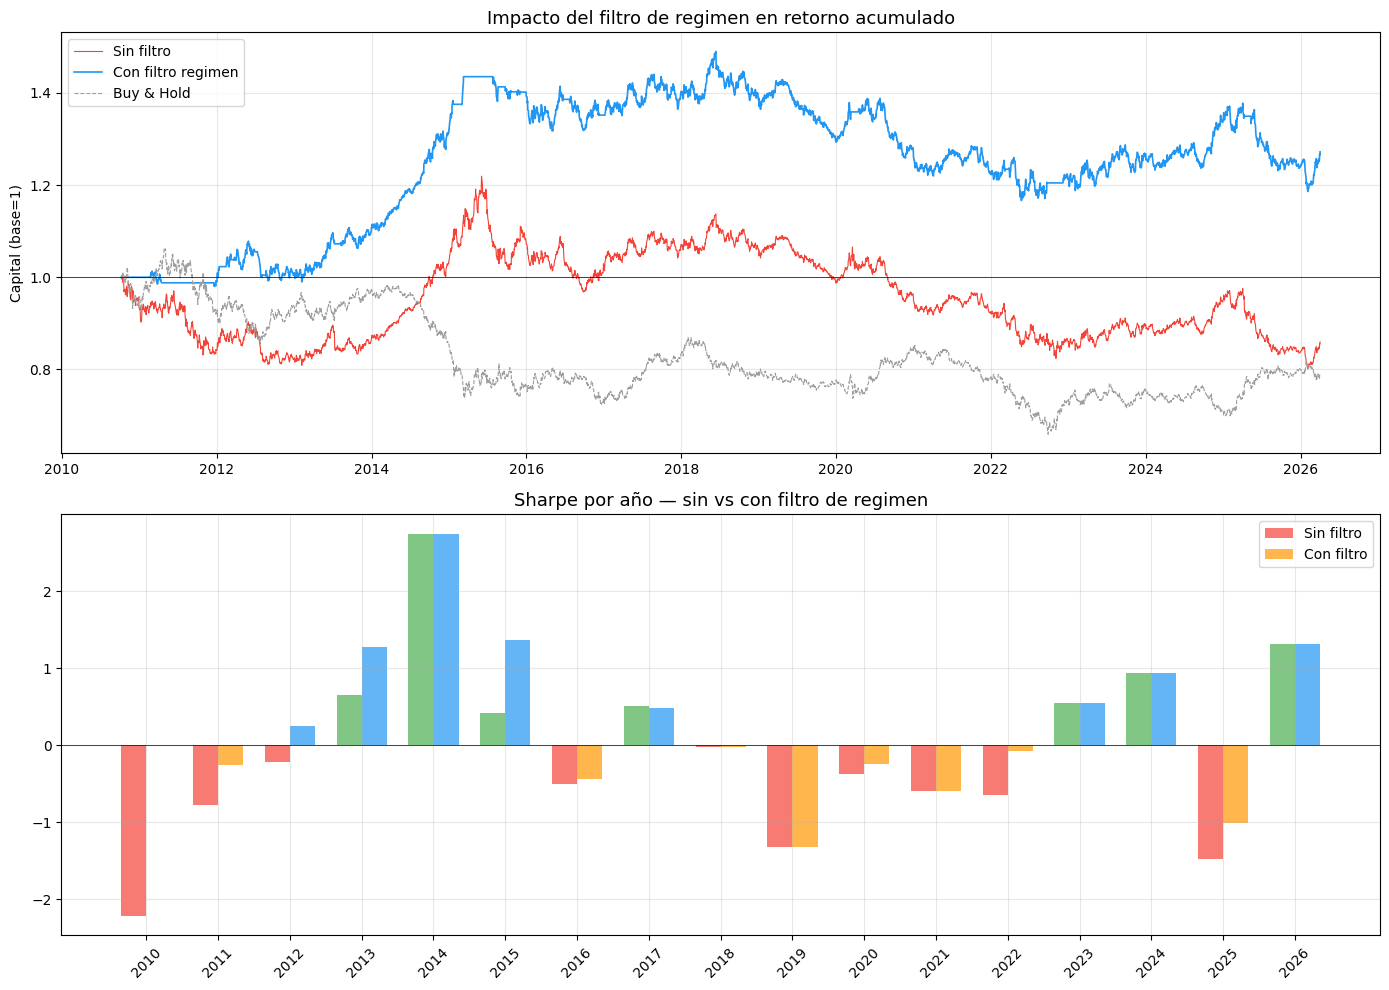

Graficas guardadas.

CONCLUSION ALPHA VALIDATION:
  Test 1 Hurst:       H=0.615 - PASA
  Test 2 Permutation: p=0.000 - PASA
  Test 3 Estabilidad: 8/17 anos - MARGINAL
  Filtro regimen:     Sharpe -0.058 -> +0.292
  Diagnostico: alpha real pero necesita filtro de regimen


In [8]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Retorno acumulado comparativo
cum_orig = (1 + data['retorno_estrategia']).cumprod()
cum_filt = (1 + data['retorno_filtrado']).cumprod()
cum_bh = (1 + data['returns']).cumprod()

axes[0].plot(data.index, cum_orig, color='#F44336', linewidth=0.8, label='Sin filtro')
axes[0].plot(data.index, cum_filt, color='#2196F3', linewidth=1.2, label='Con filtro regimen')
axes[0].plot(data.index, cum_bh, color='#9E9E9E', linewidth=0.8, linestyle='--', label='Buy & Hold')
axes[0].axhline(1, color='black', linewidth=0.5)
axes[0].set_title('Impacto del filtro de regimen en retorno acumulado', fontsize=13)
axes[0].set_ylabel('Capital (base=1)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Sharpe por año
x = np.arange(len(df_filtro))
width = 0.35
axes[1].bar(x - width/2, df_filtro['sharpe_sin_filtro'], width, 
            color=['#4CAF50' if v > 0 else '#F44336' for v in df_filtro['sharpe_sin_filtro']],
            alpha=0.7, label='Sin filtro')
axes[1].bar(x + width/2, df_filtro['sharpe_con_filtro'], width,
            color=['#2196F3' if v > 0 else '#FF9800' for v in df_filtro['sharpe_con_filtro']],
            alpha=0.7, label='Con filtro')
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].set_xticks(x)
axes[1].set_xticklabels(df_filtro['year'], rotation=45)
axes[1].set_title('Sharpe por año — sin vs con filtro de regimen', fontsize=13)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/processed/11_alpha_validation.png', dpi=150)
plt.show()

print("Graficas guardadas.")
print(f"\nCONCLUSION ALPHA VALIDATION:")
print(f"  Test 1 Hurst:       H=0.615 - PASA")
print(f"  Test 2 Permutation: p=0.000 - PASA")
print(f"  Test 3 Estabilidad: 8/17 anos - MARGINAL")
print(f"  Filtro regimen:     Sharpe -0.058 -> +0.292")
print(f"  Diagnostico: alpha real pero necesita filtro de regimen")

In [9]:
data[['retorno_estrategia', 'retorno_filtrado', 'regime']].to_csv(
    "../data/processed/alpha_validation_results.csv"
)
print("Resultados guardados.")

Resultados guardados.
